In [3]:
#Importacion de pandas y lectura del archivo.
import pandas as pd
df=pd.read_csv('25015_CULIACAN_DGE_1961_a_2016.csv',
skiprows=16, #saltamos las primeras 18 lineas del archivo
names=['FECHA','PRECIP','EVAP','TMAX','TMIN'] , #Nombres de las columnas 
sep=r'\s+',#Separamos las columnas correctamente 
na_values='Nulo', #Asignamos como nulos los datos que contengan 'Nulo'
) 

### Contabilizar numero de datos faltantes por fecha.  
Funciones y atributos utilizados:  
**1.-to_datetime():** Esta funcion convierte el tipo de dato a datetime.  
**2.-dayfirst:** Este atributo indica que el formato de la fecha es dia/mes/año. Lo utilizamos por que ese es el formato que tiene el archivo.  
**3.-dt.date:** Toma solamente la fecha del datetime dejando fuera la hora. Lo utilizamos por que no necesitamos la hora para contabilizar los dias faltantes.  
**4.-.loc:** Toma un registro determinado mediante fila-columna.  
**5.-date_range():** Crea un rango de fechas.   
**6.-difference():** Compara elementos entre dos series y guarda los elementos diferentes en otra serie.  


Lo primero que hicimos fue cambiar el tipo de dato de la columna fecha a date. Como date_time nos da el formato dia-mes-año hora:minuto:segundo utilizamos dt.date para solo obtener la fecha sin la hora.  
Despues inicializamos el rango de fechas que tiene el dataframe con date range y las fechas de inicio y final y una frecuendia en dias.  
A continuacion comparamos el rango completo con las fechas existentes en el dataframe y lo guardamos en fechas faltantes para despues imprimirlo.



In [29]:
def dias_faltantes(df):
    
    df['FECHA'] = pd.to_datetime(df['FECHA'],dayfirst=True)#Conversion de columna FECHA a datetime
    df['FECHA'] = df['FECHA'].dt.date #Tomamos solamente la fecha
    #Tomamos el rango de fechas del dataframe 1961-01-01 a 2018-07-31
    inicio=df.loc[0,'FECHA'] 
    final=df.loc[df.index[-1],'FECHA'] #.index[-1] para tomar el ultimo elemento de la columna
    rango_completo = pd.date_range(start=inicio, end=final, freq='D')
    fechas_faltantes = rango_completo.difference(df['FECHA'])
    print(f"Dias faltantes entre {inicio} y {final}: {len(fechas_faltantes)}")

#Ejecucion del metodo
dias_faltantes(df)

Dias faltantes entre 1961-01-01 y 2016-05-31: 0


### ¿Cuántos datos nos faltan por cada año?
Antes de rellenar los espacios nulos, es muy importante saber en qué años la estación dejó de reportar datos. Esto nos ayuda a ver si la falta de información es algo de un solo año o si es constante.

In [ ]:
def contar_nulos_por_anio(df_temp):
    """
    Función para contar cuántos datos faltan en cada columna, 
    separados por cada año del registro.
    """
    # Convertimos la columna de fecha a formato datetime, indicando que el día se muestra antes que el mes con el parámetro (dayfirst=True)
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)

    # Creamos la columna 'Año' extrayendo el año de la columna 'FECHA'
    df_temp['Año'] = df_temp['FECHA'].dt.year

    # Definimos las columnas numéricas que queremos analizar
    cols_clima = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']

    # Calculamos los nulos por año
    # isnull() crea True/False, al agrupar por 'Año' y usar .sum(), contamos cuántos True (nulos) hay por cada año
    nulos_por_anio = df[cols_clima].isnull().groupby(df['Año']).sum()

    # Mostramos el resultado de manera clara 
    print("--- Cantidad de datos nulos detectados por Año ---")
    display(nulos_por_anio)

    # Opcional: Ver el total general de nulos antes de proceder
    print("\nTotal de nulos en todo el registro:")
    print(df[cols_clima].isnull().sum())

    return df_temp

# Se manda a llamar la función
df = contar_nulos_por_anio(df)

--- Cantidad de datos nulos detectados por Año ---


,PRECIP,EVAP,TMAX,TMIN
Año,,,,
1961,0,0,0,0
1962,0,1,0,0
1963,0,12,9,8
1964,0,27,10,11
1965,0,1,0,0
1966,0,0,0,0
1967,2,0,0,0
1968,0,1,0,0
1969,2,0,18,29



Total de nulos en todo el registro:
PRECIP     67
EVAP      373
TMAX      113
TMIN      124
dtype: int64


## Analisis de patrones de ausencia

### Analisis cuantitativo general

**Precipitación (67)**: Muy bajo. Prácticamente no tiene faltantes relevantes. Es la variable más consistente.  
**Temperaturas Máx/Mín (113 y 124)**: Bajo/Moderado. Tienen algunos huecos aislados, pero la continuidad histórica se mantiene bastante bien.  
**Evaporación (373)**: Crítico. Concentra la inmensa mayoría de los valores "Nulo" del dataset.  

### Análisis Temporal

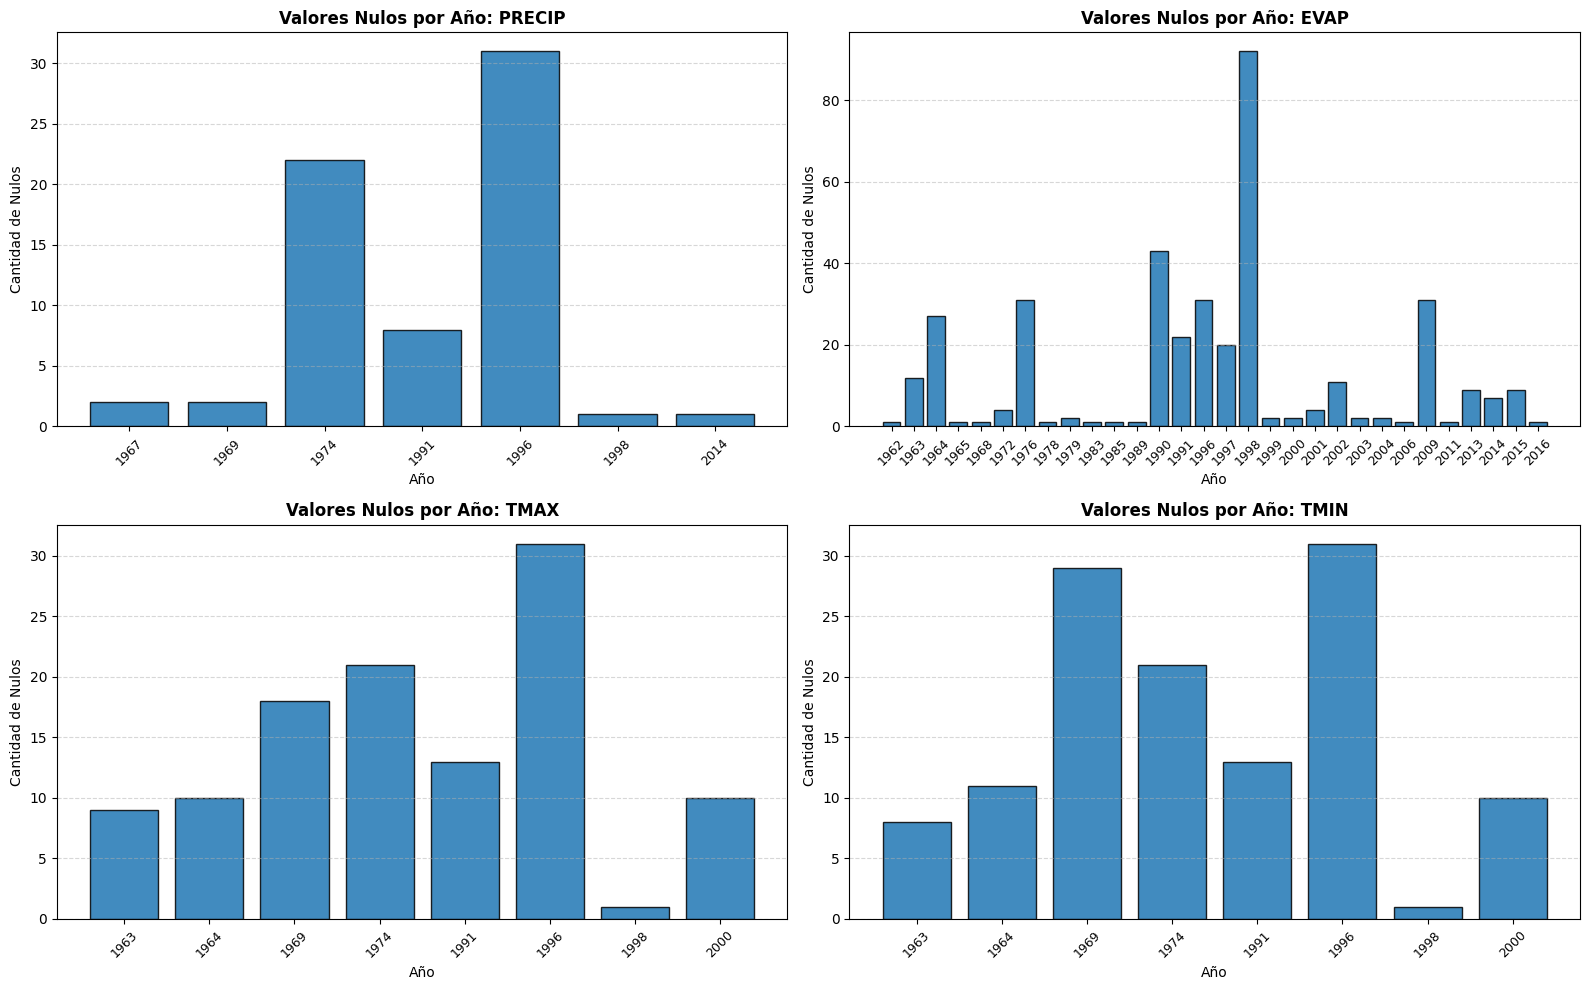

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def histograma_por_variable(df_temp):
    
    # 1. Procesar fechas y extraer el año
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)
    df_temp['AÑO'] = df_temp['FECHA'].dt.year

    cols_clima = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    
    # 2. Configurar la cuadrícula de subgráficas (2 filas x 2 columnas)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
    axes = axes.flatten() # Aplanar la matriz de 2x2 a una lista de 4 elementos para iterar fácil
    
    # 3. Iterar sobre cada columna del clima para calcular y graficar sus nulos
    for i, col in enumerate(cols_clima):
        # Agrupamos los nulos específicos de ESTA columna por año
        nulos_var = df_temp[col].isnull().groupby(df_temp['AÑO']).sum().reset_index()
        
        # Filtrar para mostrar solo los años que tienen al menos un nulo en esta variable
        nulos_var = nulos_var[nulos_var[col] > 0]
        
        # Crear la barra para la variable actual
        axes[i].bar(nulos_var['AÑO'].astype(str), nulos_var[col], edgecolor='black', alpha=0.85)
            
        # Configuraciones de estilo individuales por subgráfica
        axes[i].set_title(f'Valores Nulos por Año: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Año', fontsize=10)
        axes[i].set_ylabel('Cantidad de Nulos', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45, labelsize=9)
        axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
    # Ajustar espaciado automático entre gráficas para que no se encimen los textos
    plt.tight_layout()
    plt.show()

# Llamada a la función utilizando tu DataFrame cargado
histograma_por_variable(df)

**Precip:** Tiene muy pocos años con valores faltantes. El pico más alto apenas roza los 30 nulos en un año. La lluvia es la métrica más consistente y mejor cuidada de todo el dataset. Esto tiene mucho sentido lógico y operativo: medir si llovió o no es una de las tareas más críticas y sencillas en una estación meteorológica. Casi nunca se dejó de registrar.   
**Evap:** Es por mucho la gráfica más ruidosa y con las barras más altas. Presenta pérdidas masivas en los años 90 (rozando los 40 nulos en 1990 y más de 90 nulos en 1998) y continúa mostrando fallas constantes a lo largo de los años 2000 y 2010. Este histograma demuestra que la estación tuvo problemas crónicos con este equipo o que el personal dejó de priorizar esta medición durante múltiples periodos a lo largo de tres décadas.  
**Tmax y Tmin:** Ambas gráficas son prácticamente idénticas. Comparten exactamente los mismos picos de nulos en los mismos años (como en 1964, 1969, 1974, 1991 y 1996). Esto confirma que ambas métricas dependen del mismo proceso de captura. En las estaciones tradicionales, las temperaturas máxima y mínima se leen al mismo tiempo.

<!-- Graficando la presencia de nulos por año, saltan a la vista dos fenómenos meteorológicos/técnicos en la estación de Culiacán:

Nulos aleatorios (Días sueltos): A lo largo de las décadas de los 70s, 80s y 90s, hay pérdidas de 1 o 2 días consecutivos. Esto es completamente normal en estaciones manuales (por ejemplo, fines de semana donde nadie tomó la lectura o fallas humanas al registrar el dato).

El apagón de la Evaporación en los últimos años: Revisando las últimas filas del dataset (especialmente los años 2015 y 2016), notamos que mientras PRECIP, TMAX y TMIN siguen registrando datos con normalidad, la columna EVAP se vuelve "Nulo" de manera consecutiva durante meses enteros. Esto suele suceder porque el evaporímetro de la estación se dañó, dejó de recibir mantenimiento o el organismo encargado dejó de priorizar esa métrica en particular cerca del final del periodo de registro. -->

## Impacto en calidad de analisis e imputacion de datos

Para PRECIP, TMAX y TMIN: Como los nulos son pocos y están dispersos (días aislados), una interpolación lineal o un relleno con la media estacional está completamente justificado. No altera la tendencia real del clima en Culiacán.   

Para EVAP: Al tener bloques masivos de nulos al final del dataset, podria afecar una interpolación lineal en esos tramos largos, porque se estaria inventando algunos meses de datos planos que podrian arruinar cualquier modelo predictivo.

## 2. Metodología seleccionada para rellenar los datos (Imputación)

Para este proyecto decidímos usar la metodología **MICE (Multivariate Imputation by Chained Equations)**, que en español se conoce como Imputación Múltiple por Ecuaciones Encadenadas. Como "motor" o algoritmo base para hacer las predicciones, configuré un **Random Forest** (un enfoque que en Machine Learning se conoce comúnmente como el algoritmo MissForest).

### 2.1 ¿Cómo funciona MICE con Random Forest?
A diferencia de los métodos tradicionales que rellenan los datos de una columna mirando solo esa misma columna, MICE es **multivariado**. Esto significa que usa la información de todo el dataset para adivinar el dato que falta mediante un proceso de "vueltas" o iteraciones:

1. **Relleno temporal:** Primero hace un llenado rápido y provisional metiendo la mediana de la columna en cada hueco vacío.
2. **Predicción encadenada:** Luego va variable por variable. Por ejemplo, quita los nulos provisionales de la evaporación (`EVAP`) y entrena un *Random Forest* donde la meta es predecir la evaporación usando como pistas la lluvia (`PRECIP`), las temperaturas (`TMAX`, `TMIN`) y la fecha.
3. **Actualización:** Reemplaza los nulos con las predicciones del modelo. De inmediato pasa a la siguiente variable (como `TMAX`) y repite el proceso usando los datos que acaba de mejorar.
4. **Estabilización:** Da varias vueltas completas a todo el dataset (en este caso programé 10 vueltas). En cada vuelta, las predicciones se vuelven más exactas y realistas hasta que los datos se estabilizan.

### 2.2 ¿Por qué es la mejor opción para los datos de CONAGUA?
* **Respeta las leyes de la física y el clima:** Como vimos en el análisis del paso 1, `TMAX` y `TMIN` fallaron juntas en los mismos años porque son del mismo aparato. MICE se da cuenta de esta relación y usará la temperatura mínima de un día para calcular la máxima que falta, evitando que el modelo genere inconsistencias fisicas (como que la temperatura mínima sea mayor que la temperatura máxima).
* **Soluciona el problema de la evaporación:** La evaporación tiene huecos gigantes de meses enteros en los 90s. Si hiciéramos una línea recta para rellenarlos, los datos se verían falsos y planos. El Random Forest aprenderá cómo se comporta la evaporación cuando hace calor o cuando llueve en los años completos, y usará ese conocimiento para reconstruir los meses perdidos de forma muy natural.
* **No se confunde con la lluvia:** La lluvia casi siempre es 0 y solo sube en ciertos días. Los modelos matemáticos normales se confunden con esto, pero los árboles de decisión de Random Forest manejan estas distribuciones raras sin ningún problema.

### 2.3 Preparación de los datos (Ingeniería de Características)

Antes de pasarle los datos al modelo, tenemos que ayudarle a entender el tiempo. El clima es cíclico (diciembre y enero están pegados en el calendario, aunque uno sea el mes 12 y el otro el 1). 

Para que el algoritmo entienda la estacionalidad del año en Culiacán, extraeremos el mes y el día del año (1 al 365), y los transformaremos usando funciones de **Seno y Coseno**. Esto convierte las fechas en coordenadas circulares que el modelo procesa mucho mejor.

In [7]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
# Necesitamos esta línea porque el imputer iterativo de sklearn sigue marcado como experimental
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

def preparar_e_imputar_datos(df_input):
    # Sacamos una copia para trabajar seguros sin pisar los datos originales
    df_patched = df_input.copy()
    
    # 1. PREPARAR LAS FECHAS (Convertirlas a funciones circulares)
    df_patched['FECHA'] = pd.to_datetime(df_patched['FECHA'])
    df_patched['Mes'] = df_patched['FECHA'].dt.month
    df_patched['DOY'] = df_patched['FECHA'].dt.dayofyear  # Día del año (1 al 366)
    
    # Transformación matemática con Seno y Coseno para el mes y el día del año
    df_patched['Mes_sin'] = np.sin(2 * np.pi * df_patched['Mes'] / 12.0)
    df_patched['Mes_cos'] = np.cos(2 * np.pi * df_patched['Mes'] / 12.0)
    df_patched['DOY_sin'] = np.sin(2 * np.pi * df_patched['DOY'] / 365.25)
    df_patched['DOY_cos'] = np.cos(2 * np.pi * df_patched['DOY'] / 365.25)
    
    # 2. SELECCIONAR LAS COLUMNAS QUE VA A USAR EL MODELO
    # Metemos las variables del clima y las columnas temporales que acabamos de fabricar
    columnas_para_modelo = [
        'PRECIP', 'EVAP', 'TMAX', 'TMIN', 
        'Mes_sin', 'Mes_cos', 'DOY_sin', 'DOY_cos'
    ]
    
    X_incompleto = df_patched[columnas_para_modelo].values
    
    # 3. CONFIGURAR EL MODELO MICE (IterativeImputer)
    print("Configurando el modelo MICE con Random Forest...")
    
    # Aquí definimos el Random Forest que va a resolver las ecuaciones
    rf_regressor = RandomForestRegressor(
        n_estimators=100,       # 100 árboles para que tenga buena precisión
        max_features='sqrt',    # Evita que una sola variable domine a las demás
        random_state=42,        # Clave fija para que siempre dé el mismo resultado al correrlo
        n_jobs=-1               # Usa toda la potencia de la compu para acabar más rápido
    )
    
    # Armamos el imputador MICE
    mice_imputer = IterativeImputer(
        estimator=rf_regressor,
        max_iter=10,            # Le damos 10 vueltas al dataset para refinar los datos
        initial_strategy='median', # Con qué rellenar al inicio antes de la primera vuelta
        random_state=42,
        verbose=2               # Para que nos vaya imprimiendo el progreso en pantalla
    )
    
    # 4. CORRER EL ENTRENAMIENTO Y RELLENAR LOS DATOS
    print("Entrenando el modelo y generando los datos faltantes...")
    X_imputado = mice_imputer.fit_transform(X_incompleto)
    
    # 5. RECONSTRUIR NUESTRO DATAFRAME CON LOS DATOS NUEVOS
    df_resultado_provisional = pd.DataFrame(X_imputado, columns=columnas_para_modelo)
    
    # Reemplazamos las columnas originales que tenían nulos por las columnas ya rellenas
    for col in ['PRECIP', 'EVAP', 'TMAX', 'TMIN']:
        df_patched[col] = df_resultado_provisional[col]
        
    print("\n¡Datos rellenados con éxito!")
    return df_patched, columnas_para_modelo

# Corremos la función (Ojo: puede tardar un minuto o dos porque los árboles de decisión pesan)
df_imputado, cols_modelo = preparar_e_imputar_datos(df)

Configurando el modelo MICE con Random Forest...
Entrenando el modelo y generando los datos faltantes...
[IterativeImputer] Completing matrix with shape (20240, 8)
[IterativeImputer] Ending imputation round 1/10, elapsed time 12.06
[IterativeImputer] Change: 16.355, scaled tolerance: 0.258 
[IterativeImputer] Ending imputation round 2/10, elapsed time 22.90
[IterativeImputer] Change: 8.095, scaled tolerance: 0.258 
[IterativeImputer] Ending imputation round 3/10, elapsed time 32.68
[IterativeImputer] Change: 8.546985714285714, scaled tolerance: 0.258 
[IterativeImputer] Ending imputation round 4/10, elapsed time 42.72
[IterativeImputer] Change: 8.235466666666664, scaled tolerance: 0.258 
[IterativeImputer] Ending imputation round 5/10, elapsed time 52.85
[IterativeImputer] Change: 7.406683333333343, scaled tolerance: 0.258 
[IterativeImputer] Ending imputation round 6/10, elapsed time 61.67
[IterativeImputer] Change: 5.1138083333333375, scaled tolerance: 0.258 
[IterativeImputer] Endin

c:\Users\santi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### 2.4 Ajustes lógicos y reglas de control realistas

Los modelos de Machine Learning solo entienden de números y matemáticas, no saben de clima. Como la Inteligencia Artificial puede cometer errores lógicos mínimos por las aproximaciones, aplicaremos dos reglas de sentido común para asegurar que los datos tengan lógica meteorológica:
1. **Límites de cero:** Ni la lluvia (`PRECIP`) ni la evaporación (`EVAP`) pueden ser negativas. Si el modelo arroja un valor menor a cero (por ejemplo, -0.02), lo redondeamos a 0.
2. **Lógica de temperaturas:** Nos aseguraremos de que la temperatura mínima de un día nunca quede por encima de la temperatura máxima de ese mismo día.

In [8]:
def aplicar_restricciones_fisicas(df_check):
    df_final = df_check.copy()
    
    # Regla 1: Lluvia y Evaporación no pueden ser menores a cero
    df_final['PRECIP'] = df_final['PRECIP'].clip(lower=0.0)
    df_final['EVAP'] = df_final['EVAP'].clip(lower=0.0)
    
    # Regla 2: Revisar que la temperatura mínima no sea mayor a la máxima
    anomalias_termicas = df_final['TMIN'] > df_final['TMAX']
    cantidad_anomalias = anomalias_termicas.sum()
    
    if cantidad_anomalias > 0:
        print(f"Se detectaron {cantidad_anomalias} días donde TMIN quedó mayor a TMAX.")
        # Si llega a pasar, los intercambiamos para corregir el error del modelo
        df_final.loc[anomalias_termicas, ['TMAX', 'TMIN']] = df_final.loc[anomalias_termicas, ['TMIN', 'TMAX']].values
        print("Inconsistencias corregidas con éxito.")
    else:
        print("Revisión de temperatura perfecta: En ningún día la TMIN supera a la TMAX.")
        
    # Comprobación final para verificar que ya no tenemos ningún nulo
    print(f"\nConteo final de nulos en el nuevo dataset:")
    print(df_final[['PRECIP', 'EVAP', 'TMAX', 'TMIN']].isnull().sum())
    
    return df_final

# Ejecutamos el filtro final de control
df_final_sanado = aplicar_restricciones_fisicas(df_imputado)

Revisión de temperatura perfecta: En ningún día la TMIN supera a la TMAX.

Conteo final de nulos en el nuevo dataset:
PRECIP    0
EVAP      0
TMAX      0
TMIN      0
dtype: int64
